In [3]:
#构造 RFM 原始表
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/UserBehavior_clean.csv',
                 dtype={'user_id': str, 'item_id': str, 'category_id': str})
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = df['datetime'].dt.date
df_buy = df[df['behavior_type'] == 'buy']

snapshot = pd.to_datetime(df['date'].max())   # 观察期末 2017-12-03，作为"今天"

rfm = df_buy.groupby('user_id').agg(
    R=('date', lambda x: (snapshot - pd.to_datetime(x.max())).days),
    F=('item_id', 'count'),      # 购买次数
    M=('item_id', 'nunique'),    # 购买商品种类数（替代金额）
).reset_index()
print(rfm.describe())


                 R            F            M
count  6689.000000  6689.000000  6689.000000
mean      3.524144     3.043654     2.891165
std       2.397553     3.250811     2.924712
min       1.000000     1.000000     1.000000
25%       1.000000     1.000000     1.000000
50%       3.000000     2.000000     2.000000
75%       5.000000     4.000000     4.000000
max       9.000000    72.000000    66.000000


In [4]:
#标准化
scaler = StandardScaler()
X = scaler.fit_transform(rfm[['R', 'F', 'M']])


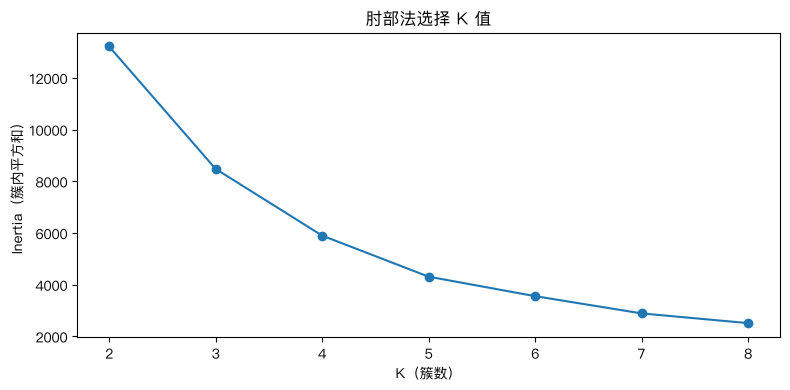

In [5]:
import matplotlib.pyplot as plt
# 设置支持中文的字体，mac上苹方 / PingFang SC
plt.rcParams['font.sans-serif'] = ['PingFang SC']
# 解决负号显示异常
plt.rcParams['axes.unicode_minus'] = False

#肘部法选择 K 值
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 9), inertias, marker='o')
plt.xlabel('K（簇数）'); plt.ylabel('Inertia（簇内平方和）')
plt.title('肘部法选择 K 值')
plt.tight_layout()
plt.savefig('../output/charts/肘部法.png', dpi=150)
plt.show()


In [6]:
#轮廓系数对比
from sklearn.metrics import silhouette_score

for k in [4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    score = silhouette_score(X, km.labels_)
    print(f'K={k}, 轮廓系数={score:.3f}')


K=4, 轮廓系数=0.481
K=5, 轮廓系数=0.466


In [7]:
#聚类 + 簇画像
k = 4   # 轮廓系数较高的 K 值
km = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm['cluster'] = km.fit_predict(X)

profile = rfm.groupby('cluster').agg(
    人数=('user_id', 'count'),
    R均值=('R', 'mean'), F均值=('F', 'mean'), M均值=('M', 'mean'),
).round(1)
print(profile)


           人数  R均值   F均值   M均值
cluster                       
0        1073  2.2   7.6   7.1
1        2017  6.6   1.8   1.7
2        3583  2.2   2.2   2.1
3          16  1.7  38.8  34.5


In [8]:
# 簇名称映射
name_map = {0: '高价值忠诚用户', 1: '早期沉睡用户', 2: '活跃潜力用户', 3: '超级用户'}
rfm['cluster_name'] = rfm['cluster'].map(name_map)
rfm.to_csv('../data/processed/UserBehavior_rfm.csv', index=False)


In [ ]:
#流失预测
df['date'] = pd.to_datetime(df['date'])

train_part = df[df['date'] < '2017-12-01']          # 前 6 天：特征原料
label_part = df[df['date'] >= '2017-12-01']          # 后 3 天：出题区

# 标签：后 3 天买过的用户 churn=0（留存），没买的 churn=1（流失）
buyers_last3 = set(label_part[label_part['behavior_type'] == 'buy']['user_id'])
users = rfm[['user_id', 'cluster', 'cluster_name']].copy()   # M3 的分层先带过来当特征
users['churn'] = (~users['user_id'].isin(buyers_last3)).astype(int)

print(users['churn'].value_counts(normalize=True))


churn
0    0.575123
1    0.424877
Name: proportion, dtype: float64


In [ ]:
#构造用户特征表
feat = train_part.groupby('user_id').agg(
    pv_count   =('behavior_type', lambda s: (s == 'pv').sum()),
    cart_count =('behavior_type', lambda s: (s == 'cart').sum()),
    fav_count  =('behavior_type', lambda s: (s == 'fav').sum()),
    buy_count  =('behavior_type', lambda s: (s == 'buy').sum()),
    active_days=('date', 'nunique'),        # 前 6 天里有几天来过
    cat_breadth=('category_id', 'nunique'), # 逛过多少类目（兴趣广度）
)

last_act = train_part.groupby('user_id')['date'].max()
feat['recency'] = (pd.Timestamp('2017-11-30') - last_act).dt.days  # 距前 6 天末几天没来

print(feat.describe().round(1))


       pv_count  cart_count  fav_count  buy_count  active_days  cat_breadth  \
count    9737.0      9737.0     9737.0     9737.0       9737.0       9737.0   
mean       56.6         3.5        1.8        1.3          4.4         17.0   
std        58.0         5.4        5.1        2.3          1.5         13.3   
min         0.0         0.0        0.0        0.0          1.0          1.0   
25%        16.0         0.0        0.0        0.0          3.0          7.0   
50%        38.0         1.0        0.0        1.0          5.0         14.0   
75%        77.0         5.0        1.0        2.0          6.0         23.0   
max       564.0        60.0      111.0       57.0          6.0        138.0   

       recency  
count   9737.0  
mean       0.4  
std        0.9  
min        0.0  
25%        0.0  
50%        0.0  
75%        1.0  
max        5.0  


In [ ]:
#合并特征表和标签表
data = users.merge(feat, on='user_id', how='left')
print('无前 6 天历史的用户数：', data['pv_count'].isnull().sum())
print(data['churn'].value_counts(), '\n', data['churn'].value_counts(normalize=True).round(3))


无前 6 天历史的用户数： 2
churn
0    3847
1    2842
Name: count, dtype: int64 
 churn
0    0.575
1    0.425
Name: proportion, dtype: float64
